# Case 3 — Reducing Missed Appointments in a Telemedicine Platform
**Winter Consulting Capstone, Consulting & Analytics Club, IIT Guwahati**

**Role:** Product Manager. **Constraint:** no full redesign, no new hardware — only flow/default/in-app changes.

**Data note:** no dataset was supplied for this case (pure product-strategy brief). `src/data_generation/generate_telemedicine_data.py` builds a 12,000-appointment event log consistent with the case's stated constraints (first-time-user share, variable connectivity, fixed doctor schedules), with a ground-truth no-show model that rewards realistic, actionable product levers.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / 'src'))
import pandas as pd
from data_generation.generate_telemedicine_data import generate
df = generate()
df.head()

Saved 12,000 rows -> /home/claude/consulting-portfolio/data/raw/telemedicine_appointments.csv  |  no-show rate: 15.7%


,appointment_id,patient_age,specialty,first_time_user,prior_completed_consults,lead_time_hours,reminder_channel,connectivity_quality,time_slot,doctor_reschedule_history,fee_prepaid,joined_late_minutes,no_show
0,1,47,Pediatrics,False,3,17.9,No Reminder,Average,Morning (9-12),0,False,3.5,0
1,2,49,Psychiatry,False,1,24.8,SMS+Push,Good,Night (8-10),0,False,0.0,0
2,3,42,Gynecology,False,1,15.0,SMS+Push,Average,Evening (4-8),0,True,NaN,1
3,4,43,Dermatology,True,0,27.0,SMS+Push+Call,Good,Evening (4-8),1,False,0.0,0
4,5,29,Psychiatry,False,4,17.2,No Reminder,Poor,Evening (4-8),1,False,5.3,0


## 1. Problem identification — grounded in system behavior, not surface symptoms

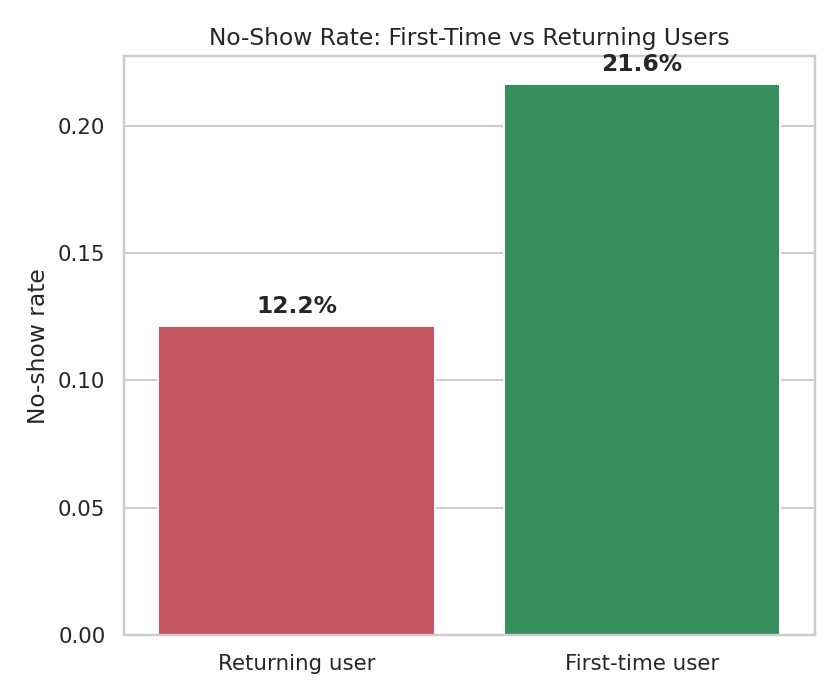

In [2]:
from case3_telemedicine.eda import load, fig1_noshow_by_firsttime, fig2_noshow_by_reminder, fig3_noshow_by_leadtime, fig4_noshow_by_connectivity_slot
df = load()
fig1_noshow_by_firsttime(df)
from IPython.display import Image, display
display(Image('../reports/figures/case3_noshow_firsttime.png'))

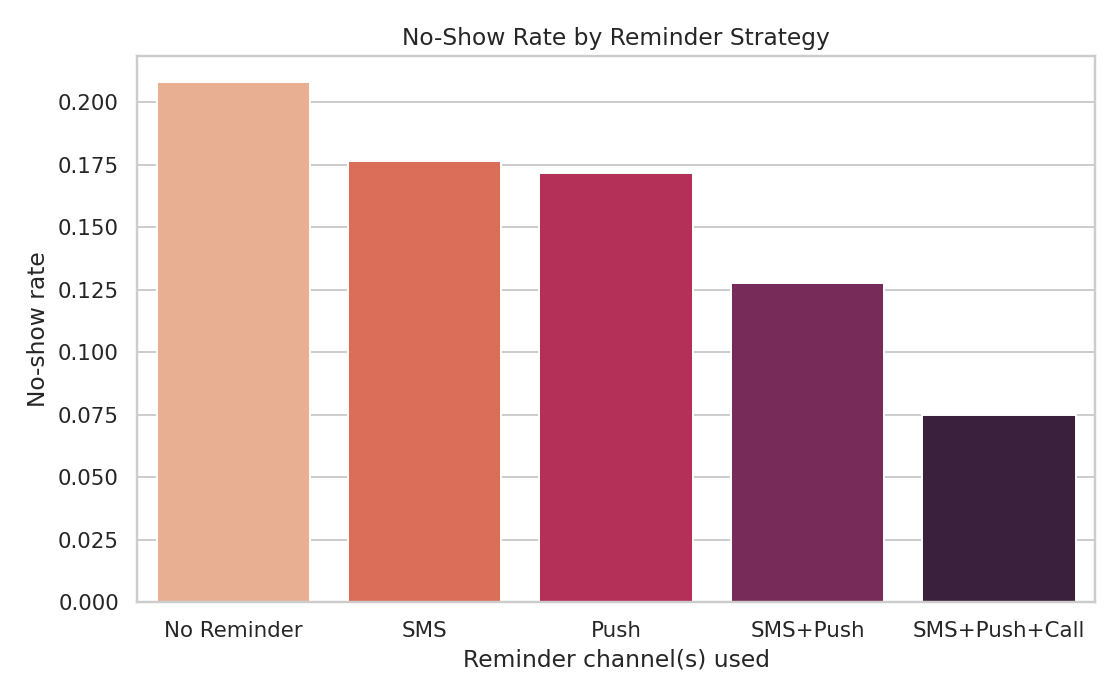

In [3]:
fig2_noshow_by_reminder(df)
display(Image('../reports/figures/case3_noshow_reminder.png'))

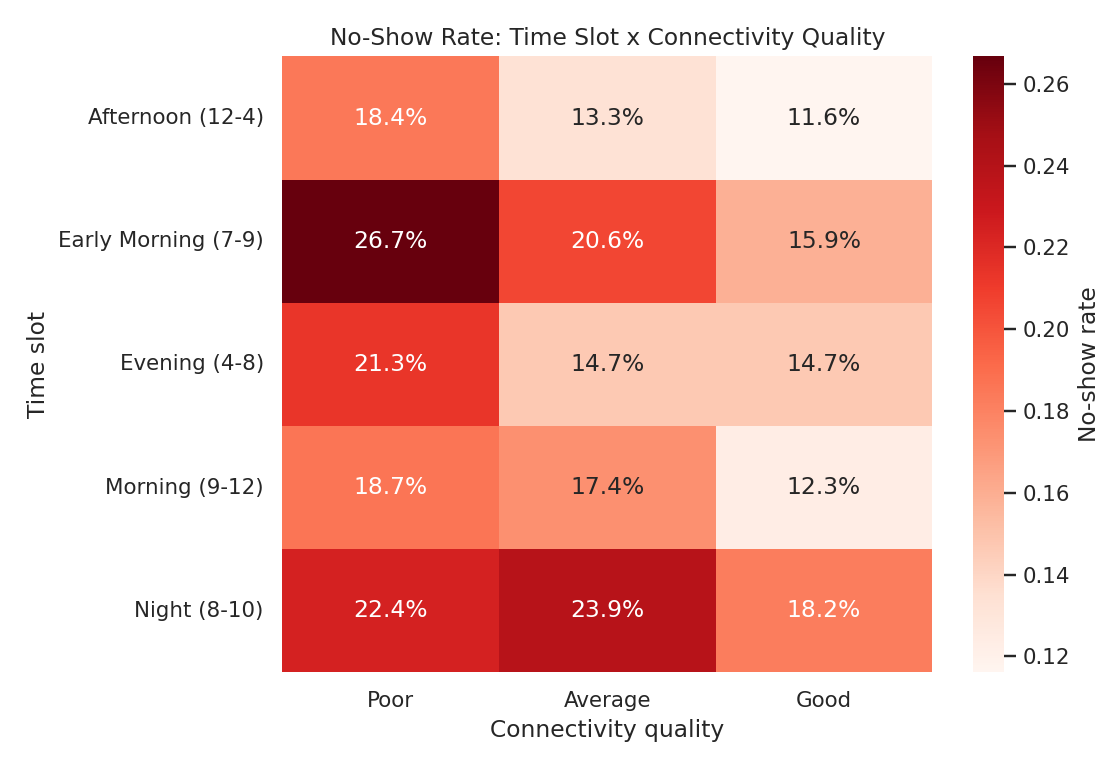

In [4]:
fig4_noshow_by_connectivity_slot(df)
display(Image('../reports/figures/case3_noshow_heatmap.png'))

## 2. No-show risk model + SHAP
A model a real product team could run in production to flag high-risk appointments for an extra nudge or proactive reschedule offer.

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[Case 3 Model] Test ROC-AUC: 0.640  (flagging top 20% highest-risk appointments)
              precision    recall  f1-score   support

           0       0.87      0.82      0.84      2529
           1       0.25      0.32      0.28       471

    accuracy                           0.74      3000
   macro avg       0.56      0.57      0.56      3000
weighted avg       0.77      0.74      0.76      3000




Top drivers of no-show risk (mean |SHAP|):
remainder__first_time_user              0.267310
cat__reminder_channel_SMS+Push+Call     0.150947
cat__reminder_channel_SMS+Push          0.124982
remainder__doctor_reschedule_history    0.123014
cat__connectivity_quality_Good          0.110357
cat__connectivity_quality_Poor          0.085347
remainder__lead_time_hours              0.080656
cat__time_slot_Afternoon (12-4)         0.076060
remainder__prior_completed_consults     0.070262
remainder__patient_age                  0.058162
cat__reminder_channel_No Reminder       0.045865
cat__time_slot_Early Morning (7-9)      0.045227
remainder__fee_prepaid                  0.029961
cat__time_slot_Night (8-10)             0.026554
cat__specialty_Dermatology              0.022356
dtype: float64


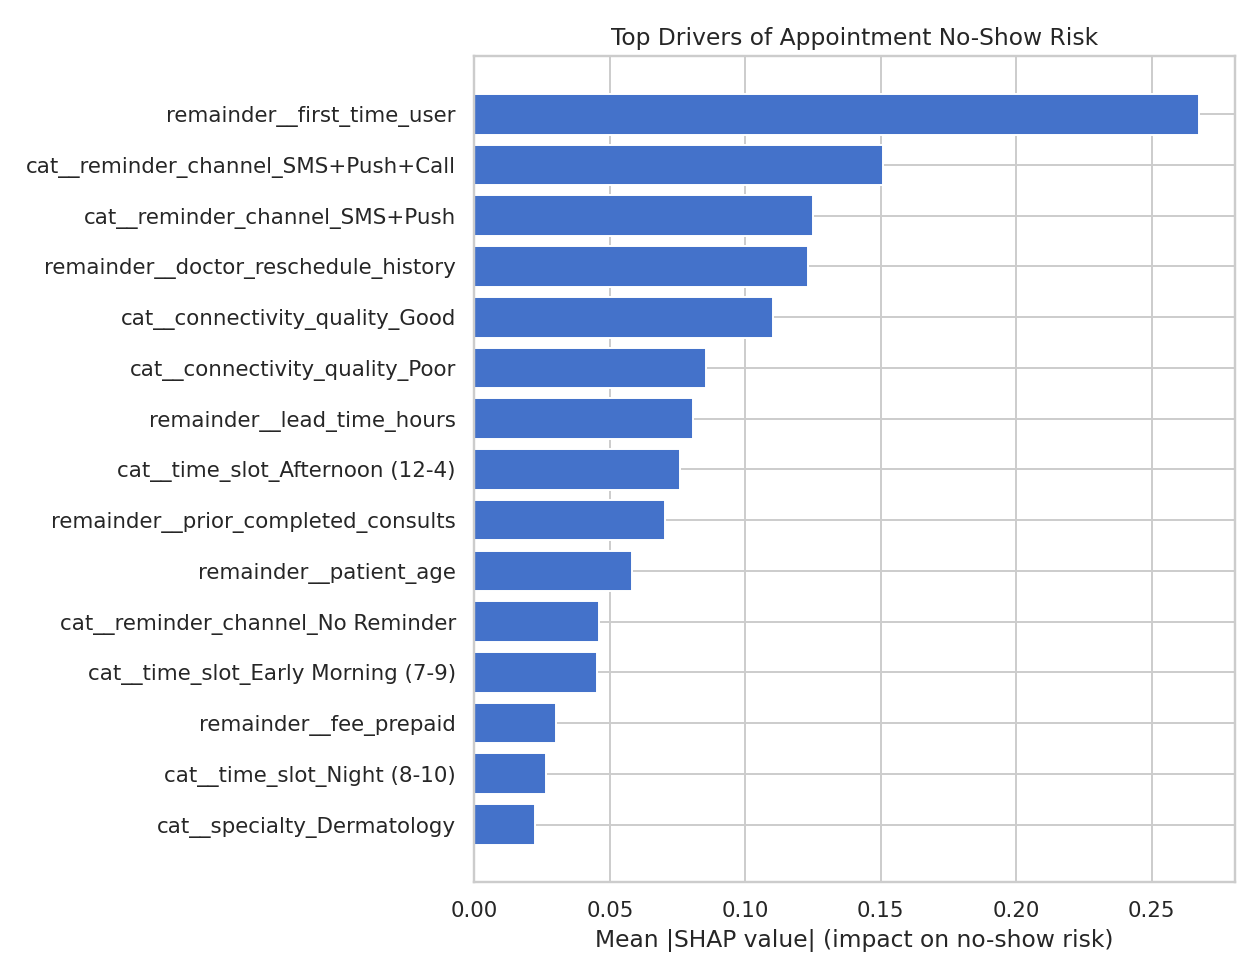

In [5]:
from case3_telemedicine.noshow_model import train
pipe, auc, mean_abs_shap = train()
display(Image('../reports/figures/case3_shap_importance.png'))

**Note on model performance:** AUC ≈ 0.64 and the top-20%-risk threshold approach (rather than default 0.5) are deliberate — no-shows are only ~16% of appointments, so a naive classifier that predicts "will show up" for everyone would look 84% accurate while being useless. The realistic framing here is: *rank* appointments by risk and act on the riskiest slice, which is exactly how a production risk-flagging feature would be used.

## 3. Solution design — quantified product levers
Three concrete, low-lift interventions (default/flow changes only, per the case's constraints), each sized using observed before/after no-show rates for comparable segments.

[Case 3 Simulation] Baseline no-show rate: 15.7%
[Case 3 Simulation] Projected no-show rate after all 3 levers: 11.6%
                                               lever  affected_appointments  \
0  Default to SMS+Push reminders (currently No Re...                   7704   
1  Pre-appointment connection-test nudge for 'Poo...                   2153   
2  T-24h re-confirmation nudge for appointments b...                    469   

   appointments_saved  est_monthly_revenue_saved  
0               418.0                   188136.0  
1                73.0                    32939.0  
2                 6.0                     2529.0  


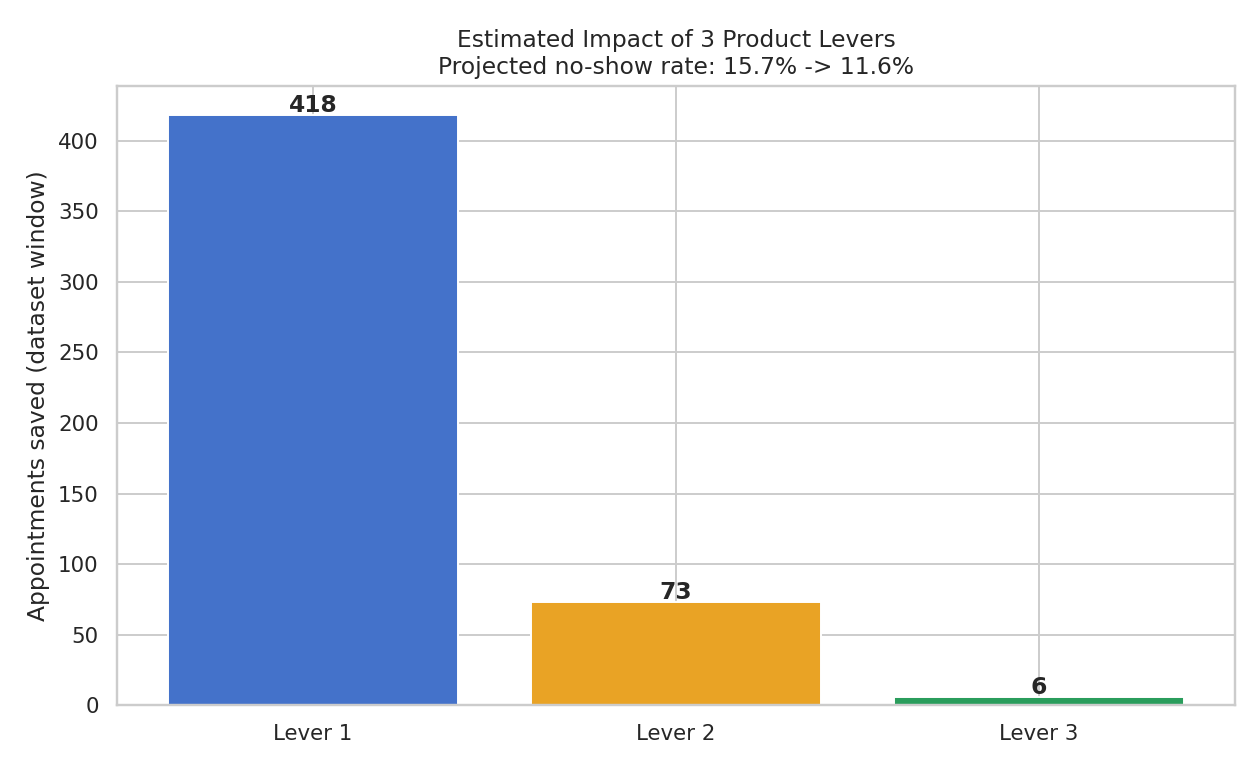

,lever,affected_appointments,baseline_rate,target_rate,appointments_saved,est_monthly_revenue_saved
0,Default to SMS+Push reminders (currently No Re...,7704,0.181983,0.127716,418.0,188136.0
1,Pre-appointment connection-test nudge for 'Poo...,2153,0.200186,0.166188,73.0,32939.0
2,T-24h re-confirmation nudge for appointments b...,469,0.168443,0.156461,6.0,2529.0


In [6]:
from case3_telemedicine.intervention_simulation import run as run_sim
impact, baseline_rate, projected_rate = run_sim()
display(Image('../reports/figures/case3_intervention_impact.png'))
impact

## 4. Recommendation & prioritization

**Primary: default all bookings to SMS+Push reminders** (currently a meaningful share get no reminder or a single channel) — largest projected impact, zero infrastructure change, pure default/flow change.

**Secondary: pre-call connectivity check nudge** for users with a history of poor connectivity — smaller impact but addresses a distinct failure mode (technical friction, not forgetting).

**Tertiary: T-24h re-confirmation nudge** for appointments booked >4 days out — smallest impact of the three, kept as a low-cost addition rather than a standalone bet.

**Why not a bigger swing (e.g. requiring pre-payment):** case brief notes most consults are pay-after-session by design; changing that is a business-model change, not a flow change, and risks suppressing first-time bookings — outside the PM's stated mandate.

**Success metrics:** primary = no-show rate (target: 15.7% → ~11.6%); supporting = doctor idle-time per week, rescheduling-related support tickets.

**Risk & mitigation:** notification fatigue from more reminders — mitigated by scoping the upgrade to users currently under-reminded, not adding a 4th channel on top of already-well-reminded users.